# Minimal Product: Task Integration Demand & Information Geometry
**Hypothesis:** Tasks requiring the integration of multiple streams (Context) will force the network to encode information synergistically. Simple accumulation tasks (Perceptual) will be solved redundantly. This effect should peak exactly at the end of the stimulus period.

We test this by training both an Elman RNN and a CTRNN to compare how temporal architectures affect the `gaussian_pid` structure.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

#import sys
#sys.path.append('../src/tasks') # Ensure Python can find data_loader.py
from src.tasks.data_loader import load_mante_data
from src.models.ctrnn import CTRNN
from src.analysis.RNN import ElmanRNN

In [23]:
# Configuration
BASE_PATH = "../src/tasks/data/tiny_test"
BATCH_SIZE = 64
SUBSAMPLE_STEP = 10 # Subsample for Elman RNN (simulate tau=10ms)

print("Loading Perceptual Datasets...")
per_train_loader = load_mante_data(f'{BASE_PATH}/perceptual/train.npz', batch_size=BATCH_SIZE, shuffle=True, subsample_step=SUBSAMPLE_STEP)
per_val_loader = load_mante_data(f'{BASE_PATH}/perceptual/val.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

print("Loading Context Datasets...")
ctx_train_loader = load_mante_data(f'{BASE_PATH}/context/train.npz', batch_size=BATCH_SIZE, shuffle=True, subsample_step=SUBSAMPLE_STEP)
ctx_val_loader = load_mante_data(f'{BASE_PATH}/context/val.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

print("All datasets loaded successfully!")

Loading Perceptual Datasets...
Loading Context Datasets...
All datasets loaded successfully!


### 1. The Architectures
We define both the Elman RNN and the CTRNN. We configure both to use `batch_first=True` for easier tensor slicing, and output the full sequence of hidden states for the PID analysis.

In [3]:
class WrappedCTRNN(nn.Module):
    def __init__(self, input_dim, hidden_size, output_size=3):
        super().__init__()
        # Use the existing CTRNN
        self.model = CTRNN(input_size=input_dim, hidden_size=hidden_size, output_size=output_size)
        
    def forward(self, x):
        # CTRNN expects (Batch, Seq, Dim). 
        # We grab outputs and hidden_states, ignoring predictions.
        outputs, _, hidden_states = self.model(x, return_dynamics=True)
        return outputs, hidden_states

class WrappedElman(nn.Module):
    def __init__(self, input_dim, hidden_size, output_size=3):
        super().__init__()
        # Use teammate's ElmanRNN, override to 80 units
        self.model = ElmanRNN(dim=input_dim, hidden_dim=hidden_size)
        # Teammate's code hardcoded output=input_dim. We overwrite it to 3 for our task classes.
        self.model.readout = nn.Linear(hidden_size, output_size) 
        
    def forward(self, x):
        # x is (Batch, Seq, Dim). 
        # Teammate's ElmanRNN forward() assumes batch=1 and seq_first.
        # We bypass their forward() and just call their internal layers directly to support batching.
        x_seq_first = x.transpose(0, 1) # Convert to (Seq, Batch, Dim)
        
        h_seq, _ = self.model.rnn(x_seq_first) 
        outputs = self.model.readout(h_seq)
        
        # Transpose back to (Batch, Seq, Features) for the training loop
        return outputs.transpose(0, 1), h_seq.transpose(0, 1)

### 2. The Data Wrapper & Masked Loss
We implement the explicit context fix for NeuroGym and write a custom loss function that only penalizes the network during the decision period (ignoring the fixation targets of `0`).

In [4]:
def masked_cross_entropy(outputs, targets):
    """Computes loss only on the decision timesteps (where target != 0)"""
    mask = targets != 0
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(outputs.device)
    
    # Flatten everything and apply the mask
    masked_outputs = outputs[mask]
    masked_targets = targets[mask]
    
    return F.cross_entropy(masked_outputs, masked_targets)

### 3. The Training Loop
We will train 4 total models: Elman vs. CTRNN on Perceptual vs. Context. We train for 500 batches to get a functional Proof of Concept.

In [19]:
def train_rnn(model, train_loader, val_loader, num_epochs=50, lr=1e-3, patience=5):
    """
    Trains an RNN with validation and early stopping.
    Only computes loss during the decision period (period == 2).
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        train_batches = 0
        
        for obs, labels, periods, cohs, ctxs in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            outputs, _ = model(obs) # outputs shape: (Batch, Time, Classes)
            
            # Mask for decision period
            mask = (periods == 2)
            if mask.sum() > 0:
                masked_outputs = outputs[mask]
                masked_labels = labels[mask]
                
                loss = criterion(masked_outputs, masked_labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item()
                train_batches += 1
                
        avg_train_loss = running_train_loss / max(1, train_batches)
        history['train_loss'].append(avg_train_loss)
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for obs, labels, periods, cohs, ctxs in val_loader:
                outputs, _ = model(obs)
                
                mask = (periods == 2)
                if mask.sum() > 0:
                    masked_outputs = outputs[mask]
                    masked_labels = labels[mask]
                    
                    loss = criterion(masked_outputs, masked_labels)
                    running_val_loss += loss.item()
                    val_batches += 1
                    
        avg_val_loss = running_val_loss / max(1, val_batches)
        history['val_loss'].append(avg_val_loss)
        
        # --- EARLY STOPPING CHECK ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Optional: Save model weights here if you want to keep the absolute best version
        else:
            patience_counter += 1
            
        # Print progress every 5 epochs
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:03d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}! Validation loss stopped improving.")
            break
            
    return history

--- Training Elman RNN on Perceptual Task ---
Epoch [001/30] | Train Loss: 1.0519 | Val Loss: 0.9392
Epoch [005/30] | Train Loss: 0.6979 | Val Loss: 0.6976
Epoch [010/30] | Train Loss: 0.6961 | Val Loss: 0.6975
Epoch [015/30] | Train Loss: 0.6940 | Val Loss: 0.6968
Early stopping triggered at epoch 14! Validation loss stopped improving.

--- Training Elman RNN on Context Task ---
Epoch [001/30] | Train Loss: 0.9872 | Val Loss: 0.8302
Epoch [005/30] | Train Loss: 0.7005 | Val Loss: 0.6987
Epoch [010/30] | Train Loss: 0.6953 | Val Loss: 0.6915
Early stopping triggered at epoch 12! Validation loss stopped improving.
--- Training CTRNN on Perceptual Task ---
Epoch [001/30] | Train Loss: 0.6982 | Val Loss: 0.6992
Epoch [005/30] | Train Loss: 0.6932 | Val Loss: 0.6932
Early stopping triggered at epoch 7! Validation loss stopped improving.

--- Training CTRNN on Context Task ---
Epoch [001/30] | Train Loss: 0.6948 | Val Loss: 0.6927
Epoch [005/30] | Train Loss: 0.6951 | Val Loss: 0.6941
Early

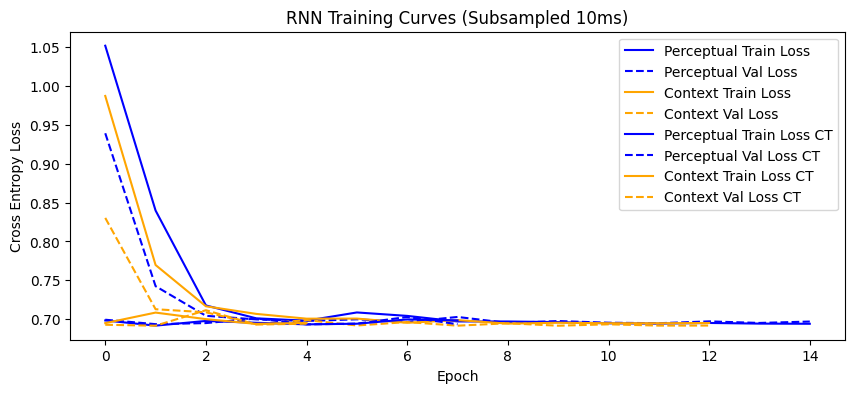

In [20]:
# Assuming your ElmanRNN is defined earlier in the notebook
# 7 input channels, 100 hidden units, 3 output choices (Fixate, Choice 1, Choice 2)
input_size = 7 
hidden_size = 80
output_size = 3

print("--- Training Elman RNN on Perceptual Task ---")
perceptual_model = WrappedElman(input_size, hidden_size, output_size)
per_history = train_rnn(perceptual_model, per_train_loader, per_val_loader, num_epochs=30, patience=3)

print("\n--- Training Elman RNN on Context Task ---")
context_model = WrappedElman(input_size, hidden_size, output_size)
ctx_history = train_rnn(context_model, ctx_train_loader, ctx_val_loader, num_epochs=30, patience=3)

print("--- Training CTRNN on Perceptual Task ---")
perceptual_model_2 = WrappedCTRNN(input_size, hidden_size, output_size)
per_history_2 = train_rnn(perceptual_model, per_train_loader, per_val_loader, num_epochs=30, patience=3)

print("\n--- Training CTRNN on Context Task ---")
context_model_2 = WrappedCTRNN(input_size, hidden_size, output_size)
ctx_history_2 = train_rnn(context_model, ctx_train_loader, ctx_val_loader, num_epochs=30, patience=3)

# Plot the training curves
plt.figure(figsize=(10, 4))
plt.plot(per_history['train_loss'], label='Perceptual Train Loss', color='blue')
plt.plot(per_history['val_loss'], label='Perceptual Val Loss', color='blue', linestyle='--')
plt.plot(ctx_history['train_loss'], label='Context Train Loss', color='orange')
plt.plot(ctx_history['val_loss'], label='Context Val Loss', color='orange', linestyle='--')
plt.plot(per_history_2['train_loss'], label='Perceptual Train Loss CT', color='blue')
plt.plot(per_history_2['val_loss'], label='Perceptual Val Loss CT', color='blue', linestyle='--')
plt.plot(ctx_history_2['train_loss'], label='Context Train Loss CT', color='orange')
plt.plot(ctx_history_2['val_loss'], label='Context Val Loss CT', color='orange', linestyle='--')
plt.title("RNN Training Curves (Subsampled 10ms)")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.show()

### 4. Time-Resolved PID Analysis
We generate a large testing ensemble (200 trials), run them through the trained networks without updating weights, and calculate the Gaussian PID at *every single timestep*. We use the final trial choice as the target variable for the PID.

In [24]:
def extract_hidden_trajectories(model, dataloader):
    """
    Runs the dataset through the model and extracts the hidden state 
    at every timestep for every trial.
    """
    model.eval()
    all_hidden = []
    all_targets = []
    all_periods = []
    
    with torch.no_grad():
        for obs, labels, periods, cohs, ctxs in dataloader:
            # We bypass the final linear layer and get the raw hidden states
            # Standard nn.RNN returns (output, h_n). 'output' contains all timesteps.
            hidden_states, _ = model.model.rnn(obs) 
            
            all_hidden.append(hidden_states.numpy())
            all_targets.append(cohs.numpy()) # Using continuous coherence as our target!
            all_periods.append(periods.numpy())
            
    # Concatenate across batches
    H = np.concatenate(all_hidden, axis=0)      # Shape: (Trials, Timesteps, Hidden_Size)
    Y = np.concatenate(all_targets, axis=0)     # Shape: (Trials,)
    P = np.concatenate(all_periods, axis=0)     # Shape: (Trials, Timesteps)
    
    return H, Y, P

print("Extracting hidden state trajectories for the Test Sets...")

# Load the dedicated Test Sets (never seen during training or validation!)
per_test_loader = load_mante_data(f'{BASE_PATH}/perceptual/test_uniform.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)
ctx_test_loader = load_mante_data(f'{BASE_PATH}/context/test_uniform.npz', batch_size=BATCH_SIZE, shuffle=False, subsample_step=SUBSAMPLE_STEP)

# Extract Trajectories
H_per, Y_per, P_per = extract_hidden_trajectories(perceptual_model, per_test_loader)
H_ctx, Y_ctx, P_ctx = extract_hidden_trajectories(context_model, ctx_test_loader)

print(f"Perceptual Trajectories Shape: {H_per.shape}")
print(f"Context Trajectories Shape:    {H_ctx.shape}")

Extracting hidden state trajectories for the Test Sets...
Perceptual Trajectories Shape: (500, 75, 80)
Context Trajectories Shape:    (500, 75, 80)


In [26]:
import numpy as np
from tqdm import tqdm # For a nice progress bar
from src.analysis.gaussian_pid import gaussian_pid

# Replace this import with your actual PID function from the project!
# from src.analysis.pid import gaussian_pid 

def calculate_time_resolved_pid(H, Y, n_splits=50):
    """
    H: Hidden states (Trials, Timesteps, Hidden_Size)
    Y: Target continuous variable (Trials,)
    n_splits: How many random 50/50 splits to average over per timestep
    """
    n_trials, n_timesteps, hidden_size = H.shape
    half_size = hidden_size // 2
    
    # Initialize arrays to store results over time
    results = {
        'synergy': np.zeros(n_timesteps),
        'redundancy': np.zeros(n_timesteps),
        'unique1': np.zeros(n_timesteps),
        'unique2': np.zeros(n_timesteps)
    }
    
    print(f"Calculating PID over {n_timesteps} timesteps...")
    
    # Loop over time
    for t in tqdm(range(n_timesteps)):
        H_t = H[:, t, :] # Shape: (Trials, Hidden_Size)
        
        syn_splits, red_splits, u1_splits, u2_splits = [], [], [], []
        
        # Average over random bipartitions
        for _ in range(n_splits):
            # Randomly shuffle indices to split the network in half
            indices = np.random.permutation(hidden_size)
            idx1, idx2 = indices[:half_size], indices[half_size:]
            
            source1 = H_t[:, idx1] # Shape: (Trials, 50)
            source2 = H_t[:, idx2] # Shape: (Trials, 50)
            
            # --- YOUR PID FUNCTION CALL HERE ---
            PID = gaussian_pid(source1, source2, Y, regularization=1e-5)
            
            # For demonstration, assuming it returns a dict:
            syn_splits.append(PID['synergy'])
            red_splits.append(PID['redundancy'])
            u1_splits.append(PID['unique1'])
            u2_splits.append(PID['unique2'])
            
        # Average the splits for this timestep
        results['synergy'][t] = np.mean(syn_splits)
        results['redundancy'][t] = np.mean(red_splits)
        results['unique1'][t] = np.mean(u1_splits)
        results['unique2'][t] = np.mean(u2_splits)
        
    return results

# Run the analysis (Warning: This might take a few minutes!)
print("--- Analyzing Perceptual Network ---")
pid_perceptual = calculate_time_resolved_pid(H_per, Y_per, n_splits=50)

print("\n--- Analyzing Context Network ---")
pid_context = calculate_time_resolved_pid(H_ctx, Y_ctx, n_splits=50)

--- Analyzing Perceptual Network ---
Calculating PID over 75 timesteps...


100%|██████████| 75/75 [00:10<00:00,  7.49it/s]



--- Analyzing Context Network ---
Calculating PID over 75 timesteps...


100%|██████████| 75/75 [00:09<00:00,  7.80it/s]


### 5. Evaluating the Hypothesis (Visualization)
We plot the Synergy and Redundancy tracks. According to our hypothesis:
1. Synergy should peak around the dotted vertical line (end of stimulus).
2. The Context task (bottom row) should have significantly higher Synergy than the Perceptual task (top row).

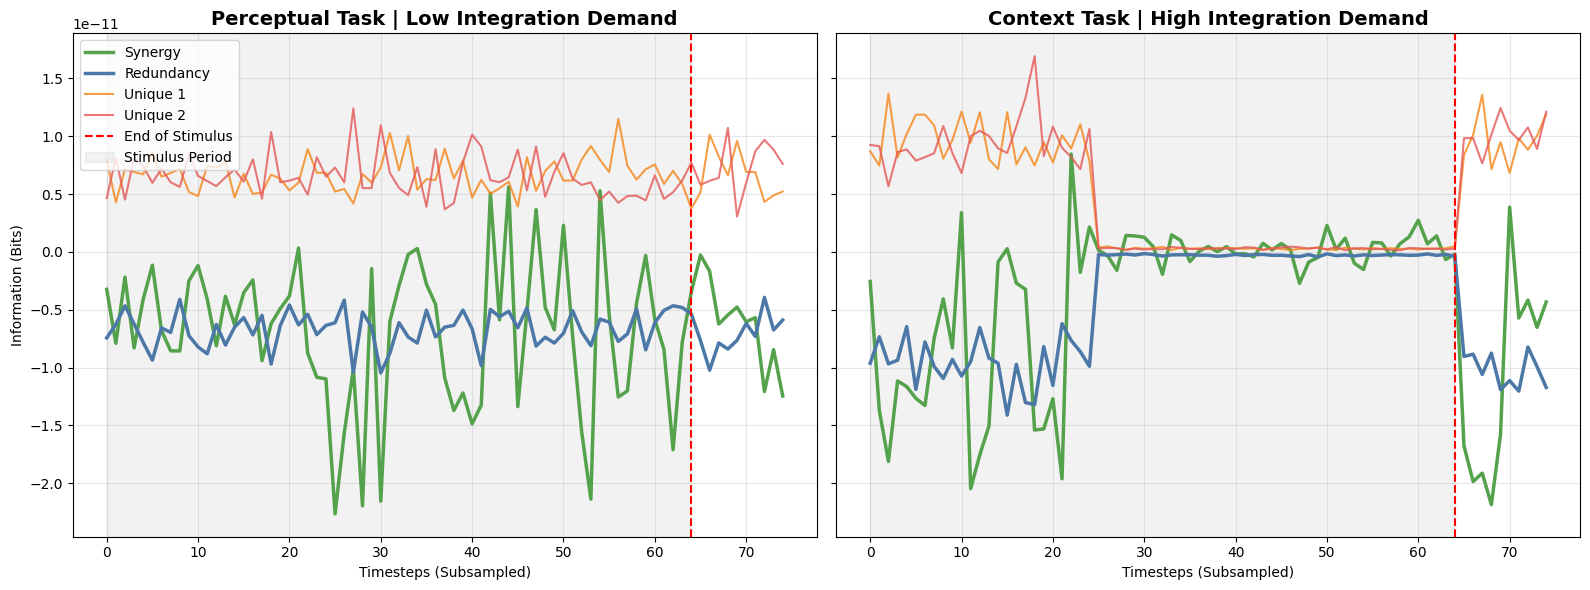

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Find the end of the stimulus period dynamically (Where period 1 transitions to 2)
# Since all trials share the same timing, we just look at the first trial
stim_end_idx = np.where(P_ctx[0] == 1)[0][-1] 
time_axis = np.arange(H_ctx.shape[1])

def plot_pid_ax(ax, data, title):
    ax.plot(time_axis, data['synergy'], label='Synergy', color='#54A24B', linewidth=2.5)
    ax.plot(time_axis, data['redundancy'], label='Redundancy', color='#4C78A8', linewidth=2.5)
    ax.plot(time_axis, data['unique1'], label='Unique 1', color='#F58518', linewidth=1.5, alpha=0.8)
    ax.plot(time_axis, data['unique2'], label='Unique 2', color='#E45756', linewidth=1.5, alpha=0.8)
    
    # Mark the End of Stimulus (The proposed snapshot)
    ax.axvline(stim_end_idx, color='red', linestyle='--', label='End of Stimulus')
    ax.axvspan(0, stim_end_idx, color='gray', alpha=0.1, label='Stimulus Period')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Timesteps (Subsampled)')
    ax.grid(alpha=0.3)

plot_pid_ax(axes[0], pid_perceptual, "Perceptual Task | Low Integration Demand")
axes[0].set_ylabel('Information (Bits)')
axes[0].legend(loc='upper left')

plot_pid_ax(axes[1], pid_context, "Context Task | High Integration Demand")

plt.tight_layout()
plt.show()